In [1]:
import pandas as pd
import matplotlib.pyplot as plt

main_df = pd.read_csv(
    "../outputs/makueni_cropland_ndvi_rainfall_anomalies_2020_2024.csv"
)

main_df["month"] = pd.to_datetime(main_df["month"])

main_df.head()

,month,mean_ndvi_cropland,rainfall_mm,rainfall_lag1,rainfall_lag2,rainfall_anomaly,rainfall_z
0,2020-01-01,0.560835,118.317911,NaN,NaN,52.284798,0.621976
1,2020-02-01,0.597665,56.757018,118.317911,NaN,-9.276095,-0.110348
2,2020-03-01,0.611866,171.246656,56.757018,118.317911,105.213543,1.251611
3,2020-04-01,0.518249,202.196964,171.246656,56.757018,136.163851,1.619794
4,2020-05-01,0.468664,22.359689,202.196964,171.246656,-43.673424,-0.519535


In [2]:
dry_threshold = main_df["rainfall_mm"].quantile(0.25)

dry_threshold

np.float64(7.057140328680212)

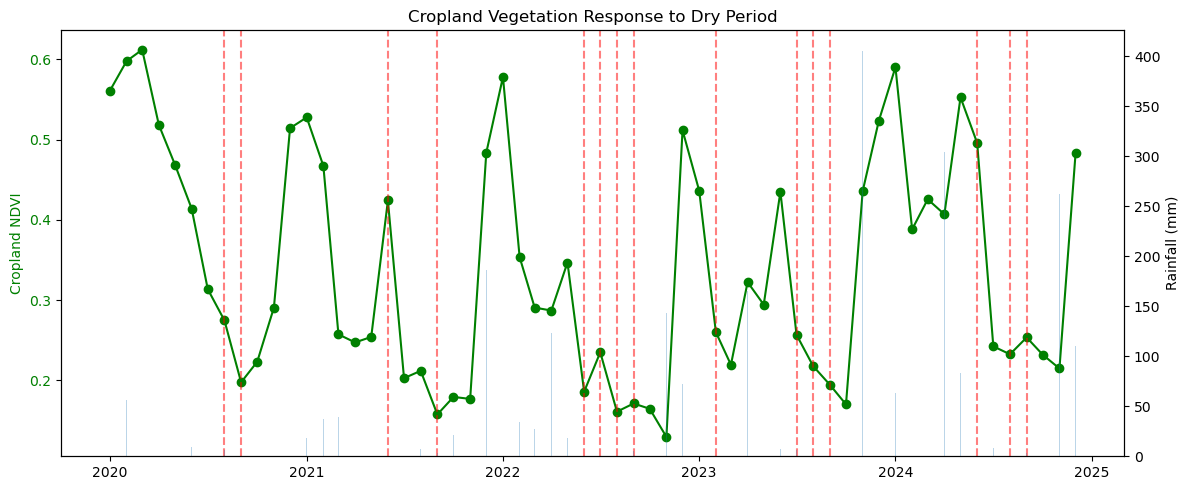

In [3]:
fig, ax1 = plt.subplots(figsize=(12,5))

ax1.plot(
    main_df["month"],
    main_df["mean_ndvi_cropland"],
    color="green",
    marker="o",
    label="Cropland NDVI"
)

ax1.set_ylabel("Cropland NDVI", color="green")
ax1.tick_params(axis="y", labelcolor="green")

ax2 = ax1.twinx()

ax2.bar(
    main_df["month"],
    main_df["rainfall_mm"],
    alpha=0.3,
    label="Rainfall"
)

ax2.set_ylabel("Rainfall (mm)")

# Highlight dry months
dry_months = main_df[
    main_df["rainfall_mm"] <= dry_threshold
]

for month in dry_months["month"]:
    ax1.axvline(
        month,
        color="red",
        linestyle="--",
        alpha=0.5
    )

plt.title("Cropland Vegetation Response to Dry Period")

fig.tight_layout()

fig.savefig(
    "../docs/images/drought_response_2020_2024.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [4]:
main_df = main_df.sort_values("month").reset_index(drop=True)

main_df["is_dry"] = (
    main_df["rainfall_mm"] <= dry_threshold
)

In [5]:
# groups consecutive dry months into the same drought event
event_ids = []
current_event_id = 0
previous_month_was_dry = False

for is_dry in main_df["is_dry"]:
    if is_dry:
        if not previous_month_was_dry:
            current_event_id += 1

        event_ids.append(current_event_id)
        previous_month_was_dry = True

    else:
        event_ids.append(pd.NA)
        previous_month_was_dry = False

main_df["drought_event_id"] = event_ids

In [6]:
main_df[
    [
        "month",
        "rainfall_mm",
        "is_dry",
        "drought_event_id"
    ]
]

,month,rainfall_mm,is_dry,drought_event_id
0,2020-01-01,118.317911,False,<NA>
1,2020-02-01,56.757018,False,<NA>
2,2020-03-01,171.246656,False,<NA>
3,2020-04-01,202.196964,False,<NA>
4,2020-05-01,22.359689,False,<NA>
5,2020-06-01,8.792400,False,<NA>
6,2020-07-01,11.160580,False,<NA>
7,2020-08-01,6.516741,True,1
8,2020-09-01,6.753315,True,1
9,2020-10-01,19.448646,False,<NA>


In [7]:
drought_events = (
    main_df[main_df["is_dry"]]
    .groupby("drought_event_id")
    .agg(
        event_start=("month", "min"),
        event_end=("month", "max"),
        duration_months=("month", "count"),
        minimum_rainfall_mm=("rainfall_mm", "min"),
        mean_rainfall_mm=("rainfall_mm", "mean"),
        total_rainfall_mm=("rainfall_mm", "sum")
    )
    .reset_index()
)

drought_events

,drought_event_id,event_start,event_end,duration_months,minimum_rainfall_mm,mean_rainfall_mm,total_rainfall_mm
0,1,2020-08-01,2020-09-01,2,6.516741,6.635028,13.270055
1,2,2021-06-01,2021-06-01,1,2.491424,2.491424,2.491424
2,3,2021-09-01,2021-09-01,1,3.359036,3.359036,3.359036
3,4,2022-06-01,2022-09-01,4,4.881197,5.113040,20.452159
4,5,2023-02-01,2023-02-01,1,3.766772,3.766772,3.766772
5,6,2023-07-01,2023-09-01,3,3.704895,5.084403,15.253208
6,7,2024-06-01,2024-06-01,1,6.949923,6.949923,6.949923
7,8,2024-08-01,2024-09-01,2,3.470424,4.643313,9.286626


In [8]:
drought_events.to_csv(
    "../outputs/makueni_candidate_drought_events_2020_2024.csv",
    index=False
)

main_df.to_csv(
    "../outputs/makueni_drought_months_and_events_2020_2024.csv",
    index=False
)